# Granite based on global behavior (sensitivity and risk) for Bike Rental Predictions

This notebook leverages GRANITE to yield regional explanations on the BikeSharing dataset using global behavior based on sensitivity and risk. We first look at minimizing disagreement due to interactions (pure vs. full) and then to minimize disagreement due to distributional influence (marginal vs. conditional)

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

# Local imports
from granite.data import get_data_bike
import numpy as np
import matplotlib.pyplot as plt

from granite.fd_trees import FDTree
from granite.plots import bar, overlay_bars

### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [3]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
features.summary()
cat_features = [0, 1, 3, 4, 5, 6]

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

In [4]:
from utils import train_gbt_bikesharing

# Fit the model, or load it if cached in models/
model = train_gbt_bikesharing(X_train, y_train)

Model already exists. Loading from disk.


In [ ]:
from granite.decompositions import get_components_tree
# Compute the H^k matrices using a subset of 1000 training points
background = X_test[:1000]
#decomposition = get_components_brute_force(model, background, background, features=features, anchored=True)
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

## Pure and Full Sobol Effects (Global Sensitivity Marginal)

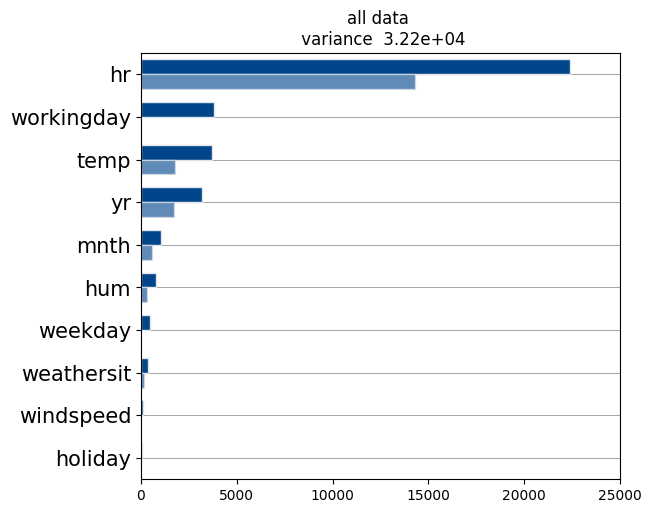

In [5]:
from granite.experiments import get_closed_total_sobol

closed_sobol_all_data, total_sobol_all_data = get_closed_total_sobol(decomposition)
bar([total_sobol_all_data, closed_sobol_all_data], features.names())
plt.xlim(0, 25000)
plt.title(f"all data \n variance {decomposition[()].var(): .2e}")
# Save plot
plt.savefig(f"../figures/bike_sensitivity_pure_full_global.pdf", bbox_inches="tight")
plt.show()

**We minimize interactions between Total and closed Sobol indices (full and pure global sensitivity measure). Splits are similar to local effects.**

In [6]:
from granite.losses import get_marginal_pure_vs_full_variance_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_variance_loss_fn(
    decomposition=decomposition,
    U=[(i,) for i in range(len(features))],
)
tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(background, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)


Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.2345
|   Samples 341
|   If hr ≤ 7.0000:
|   |   Loss 0.0018
|   |   Samples 115
|   |   Region 0
|   else:
|   |   Loss 0.1021
|   |   Samples 226
|   |   Region 1
else:
|   Loss 0.2515
|   Samples 659
|   If hr ≤ 6.0000:
|   |   Loss 0.0003
|   |   Samples 189
|   |   Region 2
|   else:
|   |   Loss 0.1922
|   |   Samples 470
|   |   Region 3
Final Loss 0.2964


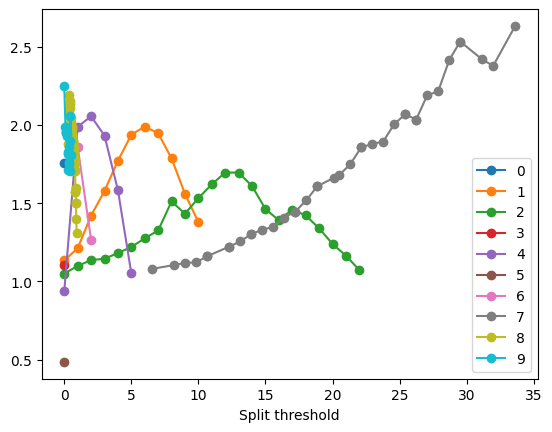

In [7]:
# Plot the loss function as a function of split candidate
plt.figure()
for i in range(len(features)):
    splits = tree.root.splits[i]
    objectives = tree.root.objectives[i]
    plt.plot(splits, objectives, '-o', label=i)
plt.xlabel("Split threshold")
plt.legend()

In [8]:
# Use the tree to compute regional decompositions
larger_background = X_test
regions = tree.predict(larger_background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
_, counts = np.unique(regions, return_counts=True)
print(counts)

[2 2 3 1 2 3 1 2 2 3]
{0: '(not workingday & hr<=7.00)', 1: '(not workingday & hr>7.00)', 2: '(workingday & hr<=6.00)', 3: '(workingday & hr>6.00)'}
[ 396  725  690 1665]


In [ ]:
#regional_decompositions = get_regional_decompositions(decomposition, regions, regions, n_regions)
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(
                                    model,
                                    regional_backgrounds[r],
                                    regional_backgrounds[r],
                                    features,
                                    anchored=True
                                )

In [ ]:
bar_plot_data = []
for r in range(tree.n_regions):
    closed_sobol, total_sobol = get_closed_total_sobol(regional_decomposition[r])
    bar_plot_data.append({"closed_sobol": closed_sobol, "total_sobol": total_sobol})
    bar([total_sobol, closed_sobol], features.names())
    plt.xlim(0, 25000)
    plt.title(f"{rules[r]} \n variance : {regional_decomposition[r][()].var():.2e} \n samples: {counts[r]} / {len(larger_background)}")
    # Save plot
    plt.savefig(f"../figures/bike_sensitivity_full_pure_region_{r}.pdf", bbox_inches="tight")

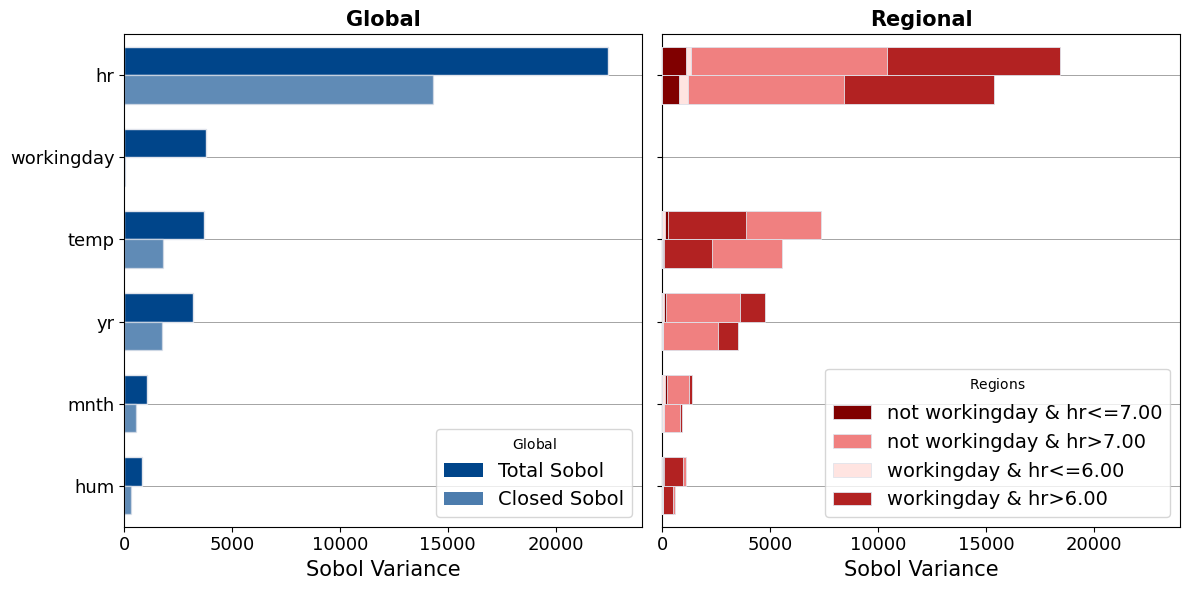

In [23]:
import matplotlib.patches as mpatches

# plot both together
fig, (ax1, ax2) = plt.subplots(
    1, 2,                     # 1 row, 2 columns
    sharey=True,              # share y-axis for alignment
    figsize=(12, 6)           # width=12 inches, height=6 inches
)

order_features = list(reversed([2, 5, 7, 0, 1, 8]))

# left plot
bar([total_sobol_all_data, closed_sobol_all_data], features.names(), ax=ax1, ordered_features=order_features)
handles = [
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        alpha=1,
        linewidth=0.6,
        label=("Total Sobol")
    ),
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        linewidth=0.6,
        alpha=0.7,
        label=("Closed Sobol")
    )
]
# add a legend on the ax1  # Dummy plot for legend
ax1.legend(handles=handles, loc="lower right", frameon=True, title="$\\bf{Global}$", fontsize=14)

# right plot
overlay_bars(
    bar_plot_data,
    features.names(),
    metric_names=["total_sobol", "closed_sobol"],
    ax=ax2,
    region_colors=['maroon', 'lightcoral', 'mistyrose', 'firebrick'],
    ordered_features=order_features,
    legend_kwargs={"loc": "lower right", "frameon": True, "title": "$\\bf{Regions}$", "fontsize": 14},
    region_labels=[f"{rules[r]}".replace("(", "").replace(")", "") for r in range(tree.n_regions)],
    add_legend=True
)

# adjust plots
fontsize = 15
for ax in [ax1, ax2]:
    ax.set_xlim(0, 24000)
    ax.set_xlabel("Sobol Variance", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax1.set_title("Global", weight="bold", fontsize=fontsize)
ax2.set_title("Regional", weight="bold", fontsize=fontsize)


plt.tight_layout()
plt.savefig("../figures/bike_sensitivity_stacked.pdf", bbox_inches="tight")
plt.show()


The bar chart on the left illustrates the pure and full sensitivity effects of each feature. We observe
strong disagreements, especially regarding `workingday` and `hr`. The right figure illustrate the regional
feature importance scores discovered by GRANITE by minimizing disagreements. We first observe that there
is hardly any variance in the model whenever it is early in the morning (all feature importance scores are negligible
since there is no variance to redistribute). Past 6-7am, the other two regions highlight some interesting trends:
- Hour remains the most important feature but disagreements between pure and full effects has been reduced.
- Workingday is no longer important since its importance is being described by the rules. 
- Temperature is more important during a non-workday than a workday, probably because high temperature drives recreational bike rentals.

## Pure vs. Full PFI (Global Risk Marginal)

In [ ]:
from granite.decompositions import get_components_tree
from granite.utils import pointwise_squared_risk
from granite.experiments import get_pure_full_risk_effects

background = X_test[:2000]
decomposition = get_components_tree(
    model,
    background,
    background,
    features=features,
    anchored=True
)


In [13]:
n_features = len(features)
risk_fn = pointwise_squared_risk
y_labels = y_test[:2000]
pure_risk, full_risk = get_pure_full_risk_effects(
    decomposition,
    y_labels,
    risk_fn,
)


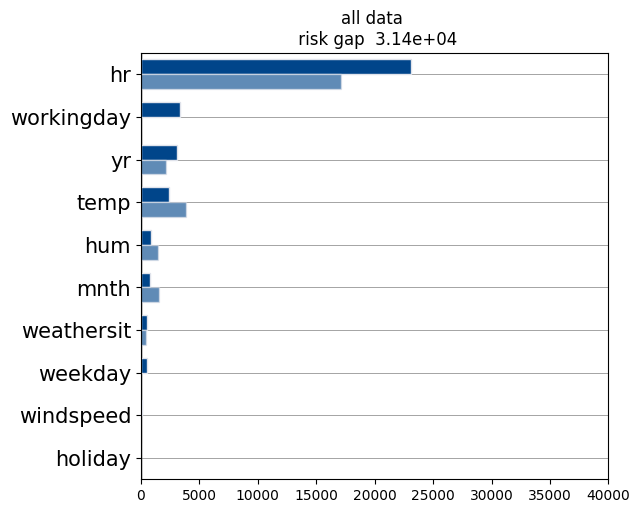

In [15]:
# nu(D) - nu(empty)
predictions = decomposition[()]
risk_gap = -risk_fn(predictions, y_labels).mean() + risk_fn(np.ones(2000)*predictions.mean(), y_labels).mean()
bar([full_risk, pure_risk], features.names())
plt.title(f"all data \n risk gap {risk_gap: .2e}")
plt.xlim(0, 40000)
plt.savefig(f"../figures/bike_risk_full_pure_global.pdf", bbox_inches="tight")

In [16]:
from granite.losses import get_marginal_pure_vs_full_risk_loss_fn

marginal_pure_vs_full_loss_fn = get_marginal_pure_vs_full_risk_loss_fn(
    decomposition=decomposition,
    U=[(i,) for i in range(n_features)],
    y=y_labels,
    risk_fn=pointwise_squared_risk
)

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(background, loss_fn=marginal_pure_vs_full_loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 2000
If yr ≤ 0.0000:
|   Loss 0.1343
|   Samples 1001
|   Region 0
else:
|   Loss 0.6640
|   Samples 999
|   If workingday ≤ 0.0000:
|   |   Loss 0.1603
|   |   Samples 324
|   |   Region 1
|   else:
|   |   Loss 0.3032
|   |   Samples 675
|   |   Region 2
Final Loss 0.5979


In [17]:
# Use the tree to compute regional decompositions
larger_background = X_test
y_background = y_test
regions = tree.predict(larger_background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
_, counts = np.unique(regions, return_counts=True)
print(counts)


[0 2 0 0 2 0 1 0 0 2]
{0: 'yr=2011', 1: '(yr=2012 & not workingday)', 2: '(yr=2012 & workingday)'}
[1714  565 1197]


In [ ]:

# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
y_region = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions == r]
    y_region[r] = y_background[regions == r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(
                                    model,
                                    regional_backgrounds[r],
                                    regional_backgrounds[r],
                                    features,
                                    anchored=True
                                )

In [24]:

risk_fn = pointwise_squared_risk
bar_plot_data = []
for r in range(tree.n_regions):
    # nu(D) - nu(empty)
    regional_pure_risk, regional_full_risk = get_pure_full_risk_effects(
        regional_decomposition[r],
        y_region[r],
        risk_fn,
    )
    bar_plot_data.append({"pure_risk": regional_pure_risk, "full_risk": regional_full_risk})

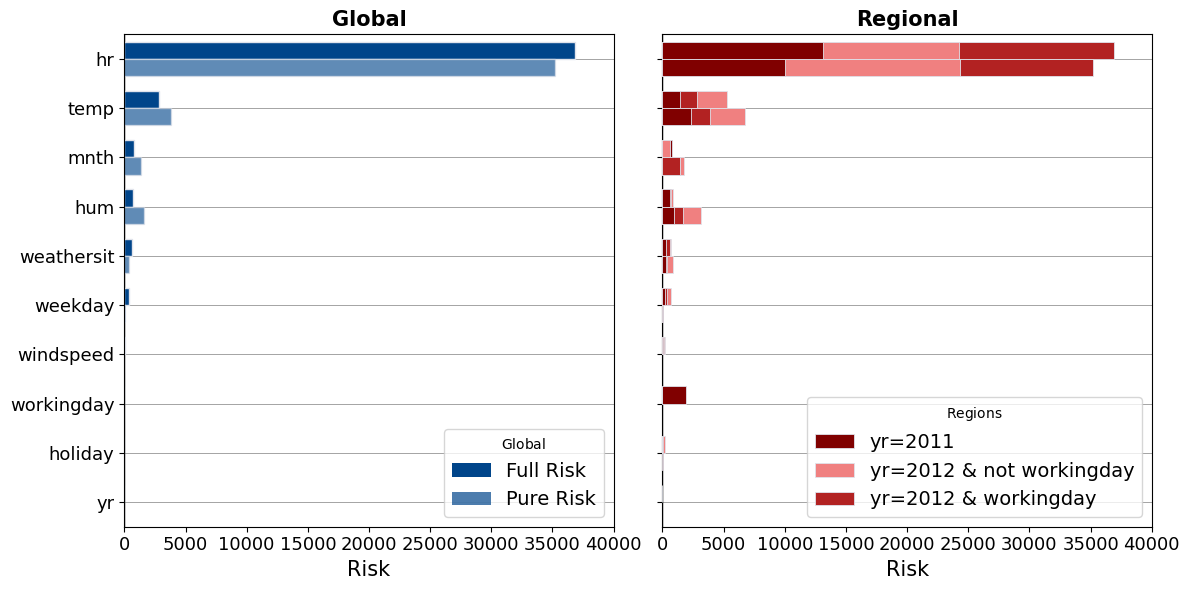

In [ ]:
import matplotlib.patches as mpatches
from granite.plots import overlay_bars

# plot both together
fig, (ax1, ax2) = plt.subplots(
    1, 2,                     # 1 row, 2 columns
    sharey=True,              # share y-axis for alignment
    figsize=(12, 6)           # width=12 inches, height=6 inches
)

order_features = list(np.argsort(full_risk))

# left plot
bar([full_risk, pure_risk], features.names(), ax=ax1, ordered_features=order_features)
handles = [
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        alpha=1,
        linewidth=0.6,
        label=("Full Risk")
    ),
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        linewidth=0.6,
        alpha=0.7,
        label=("Pure Risk")
    )
]
# add a legend on the ax1  # Dummy plot for legend
ax1.legend(handles=handles, loc="lower right", frameon=True, title="$\\bf{Global}$", fontsize=14)

# right plot
overlay_bars(
    bar_plot_data,
    features.names(),
    metric_names=["full_risk", "pure_risk"],
    ax=ax2,
    region_colors=['maroon', 'lightcoral', 'firebrick'],
    ordered_features=order_features,
    legend_kwargs={"loc": "lower right", "frameon": True, "title": "$\\bf{Regions}$", "fontsize": 14},
    region_labels=[f"{rules[r]}".replace("(", "").replace(")", "") for r in range(tree.n_regions)],
    add_legend=True
)

# adjust plots
fontsize = 15
for ax in [ax1, ax2]:
    ax.set_xlim(0, 40000)
    ax.set_xlabel("Risk", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize - 2)
ax1.set_title("Global", weight="bold", fontsize=fontsize)
ax2.set_title("Regional", weight="bold", fontsize=fontsize)

plt.tight_layout()
plt.show()


**We calculate SAGE globally and within the regions found by minimizing interactions between full and pure global risk (PFI)**

In [31]:
# setup what you want to explain
from shapiq import InteractionValues

index = "k-SII"
order = 2
rules[-1] = "Whole Data"

In [32]:
# prepare and collect the data for shapiq
n_features = len(features)
n_samples_local = 100

x_explain_regions: dict[int, np.ndarray] = {}
data_regions: dict[int, np.ndarray] = {}
y_regions: dict[int, np.ndarray] = {}
for r in range(tree.n_regions):
    data_region = larger_background[regions==r]
    y_region = y_background[regions == r]
    x_explain_regions[r] = data_region[:n_samples_local].copy()
    data_regions[r] = data_region.copy()
    y_regions[r] = y_region.copy()
    print(f"Region {r} {rules[r]} n_samples: {len(data_region)} y_regions: {len(y_region)}")

# concatenate via rows
data_global = np.concatenate([data_regions[r] for r in data_regions], axis=0)
y_global = np.concatenate([y_regions[r] for r in y_regions], axis=0)
x_explain_global = np.concatenate([x_explain_regions[r] for r in x_explain_regions], axis=0)
print(f"Global n_samples: {len(data_global)}")
x_explain_regions[-1] = x_explain_global
data_regions[-1] = data_global
y_regions[-1] = y_global

Region 0 yr=2011 n_samples: 1714 y_regions: 1714
Region 1 (yr=2012 & not workingday) n_samples: 565 y_regions: 565
Region 2 (yr=2012 & workingday) n_samples: 1197 y_regions: 1197
Global n_samples: 3476


In [33]:
from shapiq import AgnosticExplainer

from granite.shapiq_games import GlobalRiskGame
from sklearn.metrics import mean_absolute_error

ivs_global: dict[int, list[InteractionValues]] = {}

# explain in the regions and the whole data
for r in rules:
    print(f"Region {r} - {len(data_regions[r])} background samples - rule: {rules[r]}")
    # do the explanations in the region
    game = GlobalRiskGame(
        data=data_regions[r],
        y_true=y_regions[r],
        model=model.predict,
        loss_function=mean_absolute_error,
        n_expectation_rounds=50,
    )
    explainer = AgnosticExplainer(
        game=game,
        index=index,
        max_order=order,
    )
    explainer.game.verbose = True
    iv_region = explainer.explain(budget=2**n_features)
    print(iv_region)
    ivs_global[r] = iv_region
    iv_region.save(pathlib.Path("iv_bike_global_region_" + str(r) + ".json"))

Region 0 - 1714 background samples - rule: yr=2011


Evaluating game: 100%|██████████| 1024/1024 [02:49<00:00,  6.04 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=109.51976279308504,
    Top 10 interactions:
        (): 109.51976279308504
        (1, 7): 4.544978879329585
        (2, 4): -2.9056401529828864
        (2, 7): -3.6084798290509097
        (8,): -4.230009726478941
        (1, 2): -4.332993853623961
        (1,): -5.420928516326068
        (7,): -9.686738292293736
        (2, 5): -12.391399509828709
        (2,): -43.03957829998914
)
Region 1 - 565 background samples - rule: (yr=2012 & not workingday)


Evaluating game: 100%|██████████| 1024/1024 [01:26<00:00, 11.80 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=167.51796307641024,
    Top 10 interactions:
        (): 167.51796307641024
        (1, 7): 5.563262241710635
        (2, 8): 4.094624688352973
        (2, 4): -3.9871677482875207
        (1,): -4.1932534378272805
        (1, 2): -4.2628922757604295
        (8,): -7.2967834648500824
        (2, 7): -13.445593347429913
        (7,): -18.719993737514006
        (2,): -80.77587198113198
)
Region 2 - 1197 background samples - rule: (yr=2012 & workingday)


Evaluating game: 100%|██████████| 1024/1024 [02:09<00:00,  7.92 coalition/s]


InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=167.39094342183824,
    Top 10 interactions:
        (): 167.39094342183824
        (1, 7): 2.586445153847572
        (2, 4): -1.9432250156837156
        (2, 6): -3.1445282707487654
        (1,): -3.7936991878685125
        (8,): -4.887223602692258
        (1, 2): -5.065323393331411
        (2, 7): -8.91329527634653
        (7,): -10.731952564047708
        (2,): -103.69964373597332
)
Region -1 - 3476 background samples - rule: Whole Data


Evaluating game: 100%|██████████| 1024/1024 [04:32<00:00,  3.75 coalition/s]

InteractionValues(
    index=k-SII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=144.63416933576403,
    Top 10 interactions:
        (): 144.63416933576403
        (1, 7): 4.034692825992931
        (1,): -3.353164556009519
        (2, 7): -3.474107326264972
        (2, 4): -4.448867880347771
        (8,): -4.910407203133443
        (0, 2): -7.839375641415381
        (7,): -10.685696889058066
        (2, 5): -15.573459121615258
        (2,): -55.272934116450486
)


In [34]:
# find the min and max values of all global ivs
min_iv = np.inf
max_iv = -np.inf
for r, ivs in ivs_global.items():
    iv_first = ivs.get_n_order(min_order=1, max_order=1)
    min_iv = min(np.min(iv_first), min_iv)
    max_iv = max(np.max(iv_first), max_iv)
print(min_iv, max_iv)

-103.69964373597332 1.9081752681429212


'Region 0 - rule: yr=2011'

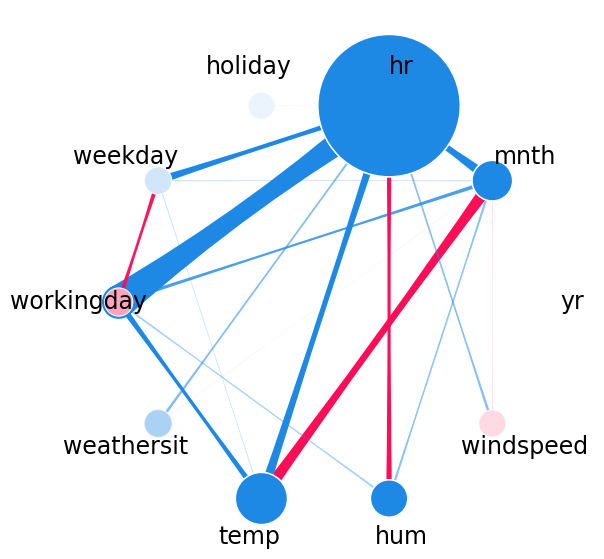

'Region 1 - rule: (yr=2012 & not workingday)'

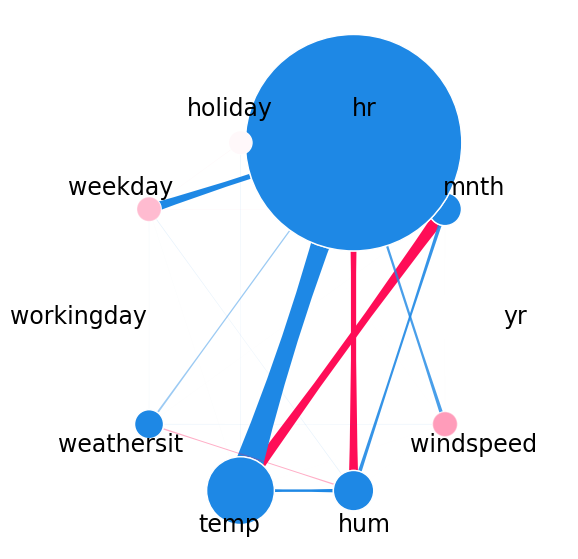

'Region 2 - rule: (yr=2012 & workingday)'

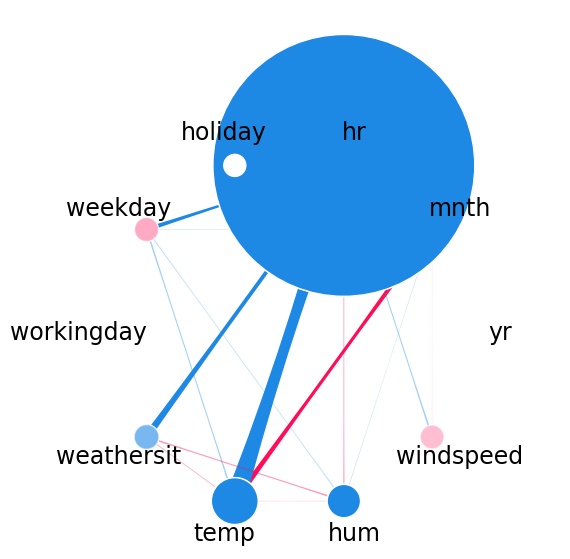

'Region -1 - rule: Whole Data'

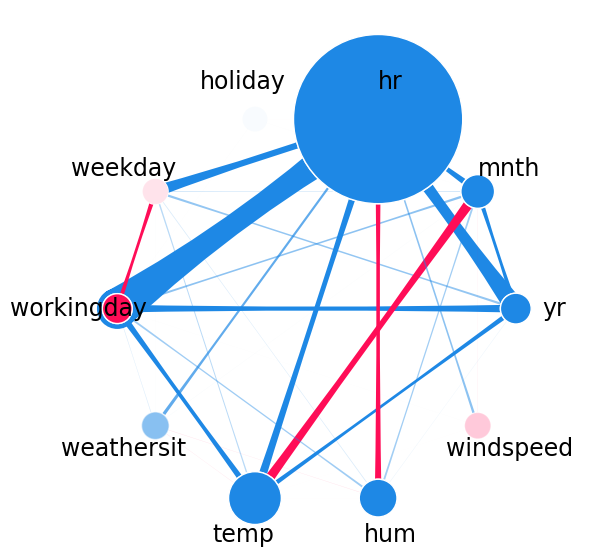

In [35]:
from shapiq import si_graph_plot

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 16})

for r, ivs_region in ivs_global.items():
    display(f"Region {r} - rule: {rules[r]}")
    si_graph_plot(ivs_region, show=False, feature_names=features.names(), min_max_interactions=(min_iv, max_iv), size_factor=0.5)
    plt.savefig(f"../figures/sage_full_pure_region_{r}.pdf", bbox_inches="tight")
    plt.show()

# Conditional vs. Marginal Sobol (global sensitivity)

In [ ]:
from granite.experiments import get_marginal_conditional_sobol
from granite.utils import create_bins_for_data_partition_tree

background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)



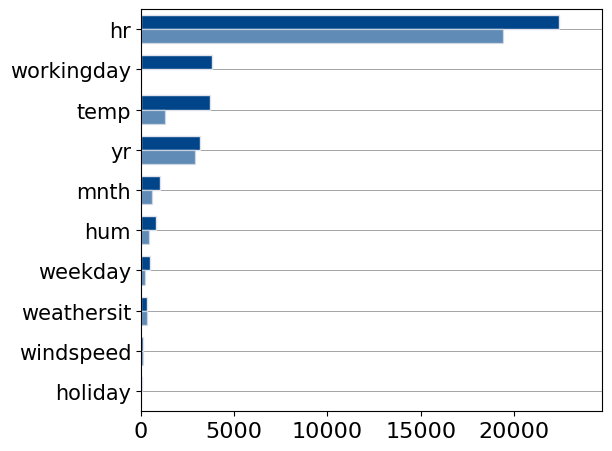

In [38]:
bins, binned_features = create_bins_for_data_partition_tree(
    background, cat_feature_indices=cat_features, max_leaf_nodes=10
)
marginal_sobol, cond_sobol = get_marginal_conditional_sobol(
    binned_features,
    decomposition
)

bar([marginal_sobol, cond_sobol], features.names())

In [39]:
from granite.losses import get_marginal_vs_condition_full_variance_loss_fn

marginal_vs_conditional_full_variance_loss_fn = \
get_marginal_vs_condition_full_variance_loss_fn(
    decomposition=decomposition,
    U=[(i,) for i in range(n_features)],
    binned_features=binned_features
)

tree = FDTree(features, max_depth=2, save_losses=True, branching_per_node=1)
tree.fit(background, loss_fn=marginal_vs_conditional_full_variance_loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
Region 0
Final Loss 1.0000


**No regions found**


## Marginal-vs-Conditional Risk Effect
PFI versus CPFI

In [ ]:
from granite.decompositions import get_components_tree
from granite.experiments import get_marginal_conditional_full_risk
from granite.utils import create_bins_for_data_partition_tree, decomposition_to_R, pointwise_squared_risk

background = X_test[:1000]
decomposition = get_components_tree(model, background, background, features=features, anchored=True)

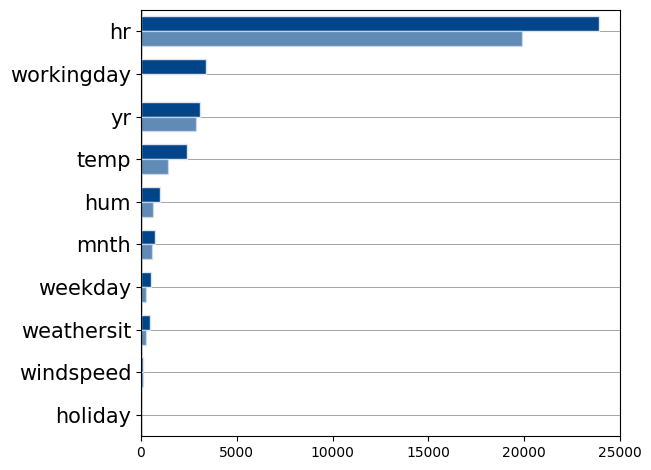

In [24]:
bins, binned_features = create_bins_for_data_partition_tree(
    background, cat_feature_indices=cat_features, max_leaf_nodes=5
)
y_labels = y_test[:1000]
risk_fn = pointwise_squared_risk
marginal_risk, cond_risk = get_marginal_conditional_full_risk(
    binned_features,
    decomposition,
    y_labels,
    risk_fn,
)

bar([marginal_risk, cond_risk], features.names())
plt.xlim(0, 25000)
plt.savefig(f"../figures/bike_pfi_cfi_global.pdf", bbox_inches="tight")

In [8]:
from granite.losses import get_marginal_vs_condition_full_risk_loss_fn

marginal_vs_conditional_full_risk_loss_fn =  get_marginal_vs_condition_full_risk_loss_fn(
    decomposition=decomposition,
    U=[(i,) for i in range(len(features))],
    binned_features=binned_features,
    y=y_labels,
    risk_fn=risk_fn
)
tree = FDTree(features, alpha=0.1, max_depth=2, save_losses=True, branching_per_node=3)
tree.fit(background, loss_fn=marginal_vs_conditional_full_risk_loss_fn)
tree.print(verbose=True)

Loss 1.0000
Samples 1000
If workingday ≤ 0.0000:
|   Loss 0.3115
|   Samples 341
|   If hr ≤ 7.0000:
|   |   Loss 0.0001
|   |   Samples 115
|   |   Region 0
|   else:
|   |   Loss 0.0416
|   |   Samples 226
|   |   Region 1
else:
|   Loss 0.2975
|   Samples 659
|   If hr ≤ 5.0000:
|   |   Loss 0.0000
|   |   Samples 161
|   |   Region 2
|   else:
|   |   Loss 0.0363
|   |   Samples 498
|   |   Region 3
Final Loss 0.0780


In [9]:
# decomposition for a larger background
larger_background = X_test
regions = tree.predict(larger_background)
print(regions[:10])
n_regions = tree.n_regions
rules = tree.rules()
print(rules)
larger_y_labels = y_test
larger_bins, larger_binned_features = create_bins_for_data_partition_tree(
    larger_background, cat_feature_indices=cat_features, max_leaf_nodes=5
)

[3 2 3 1 2 3 1 2 2 3]
{0: '(not workingday & hr<=7.00)', 1: '(not workingday & hr>7.00)', 2: '(workingday & hr<=5.00)', 3: '(workingday & hr>5.00)'}


In [ ]:
# get regional decomposition and binning for regions
regional_risk = [0.0] * n_regions
regional_targets = [[]] * n_regions
regional_binned_features = [[]] * n_regions
regional_decomposition = [[]] * n_regions
for r in range(n_regions):
    regional_binned_features[r] = [[]] * len(features)
    in_region = regions == r
    regional_decomposition[r] = get_components_tree(
        model,
        larger_background[in_region],
        larger_background[in_region],
        features=features,
        anchored=True,
    )
    regional_targets[r] = larger_y_labels[in_region]
    regional_risk[r] = risk_fn(regional_decomposition[r][()], regional_targets[r]).mean()
    for i in range(len(features)):
        regional_binned_features[r][i] = larger_binned_features[i][in_region]

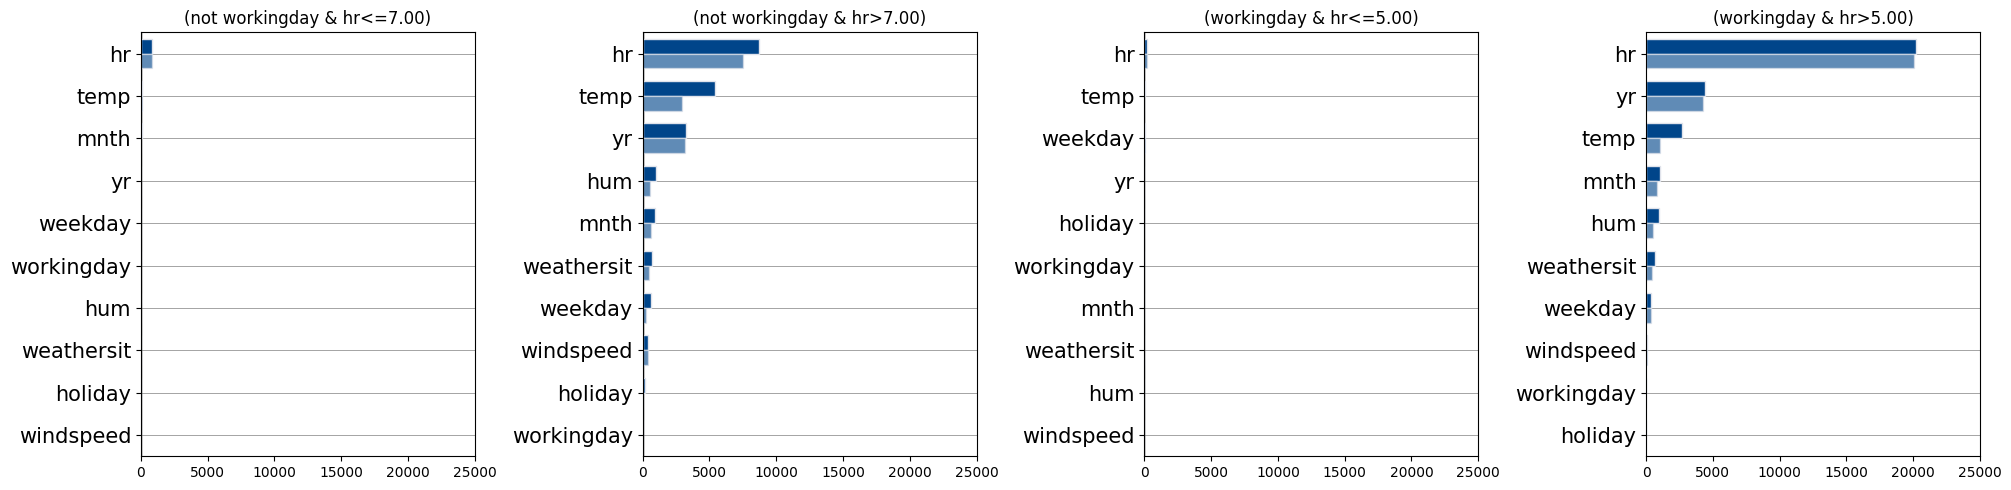

In [25]:
fig, axes = plt.subplots(1, n_regions, figsize=(5*n_regions, 5))
bar_plot_data = []
for r in range(tree.n_regions):
    regional_marginal_risk, regional_cond_risk = get_marginal_conditional_full_risk(
        regional_binned_features[r],
        regional_decomposition[r],
        y=regional_targets[r],
        risk_fn=risk_fn,
    )
    bar_plot_data.append({"PFI": regional_marginal_risk, "CFI": regional_cond_risk})
    bar([regional_marginal_risk, regional_cond_risk], features.names(), ax=axes[r])
    axes[r].set_xlim(0, 25000)
    axes[r].set_title(rules[r])
plt.savefig(f"../figures/bike_pfi_cfi_regional.pdf", bbox_inches="tight")

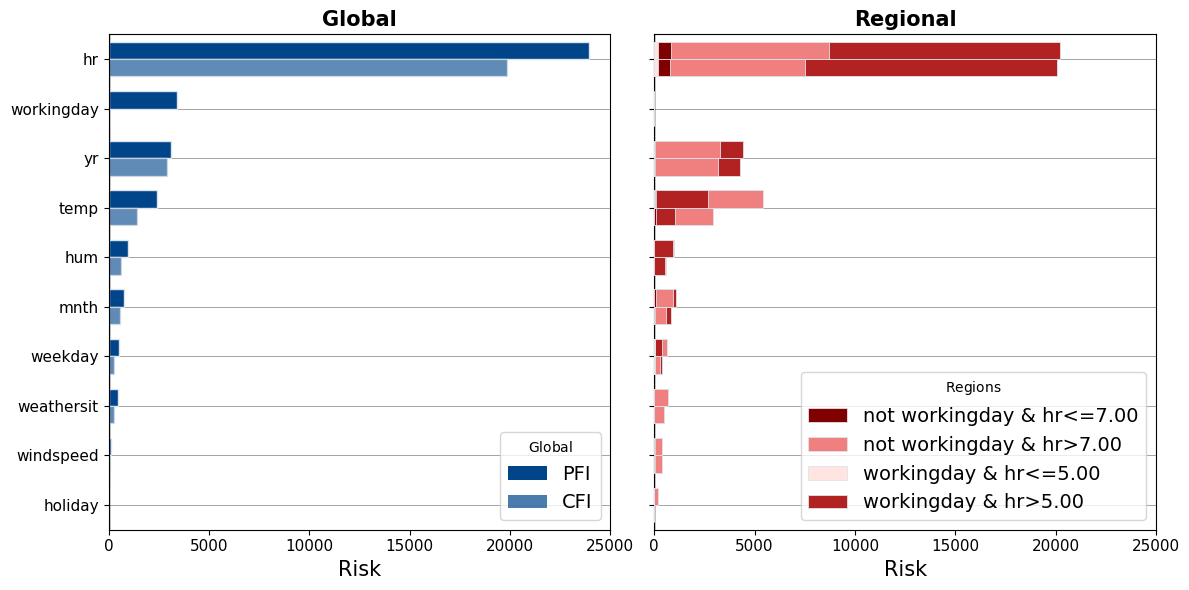

In [31]:
import matplotlib.patches as mpatches
from granite.plots import overlay_bars

# plot both together
fig, (ax1, ax2) = plt.subplots(
    1, 2,                     # 1 row, 2 columns
    sharey=True,              # share y-axis for alignment
    figsize=(12, 6)           # width=12 inches, height=6 inches
)

order_features = list(np.argsort(marginal_risk))

# left plot
bar([marginal_risk, cond_risk], features.names(), ax=ax1, ordered_features=order_features)
handles = [
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        alpha=1,
        linewidth=0.6,
        label=("PFI")
    ),
    mpatches.Patch(
        facecolor=np.array([0, 69, 138])/ 255.0,
        linewidth=0.6,
        alpha=0.7,
        label=("CFI")
    )
]
# add a legend on the ax1  # Dummy plot for legend
ax1.legend(handles=handles, loc="lower right", frameon=True, title="$\\bf{Global}$", fontsize=14)

# right plot
overlay_bars(
    bar_plot_data,
    features.names(),
    metric_names=["PFI", "CFI"],
    ax=ax2,
    region_colors=['maroon', 'lightcoral', 'mistyrose', 'firebrick'],
    ordered_features=order_features,
    legend_kwargs={"loc": "lower right", "frameon": True, "title": "$\\bf{Regions}$", "fontsize": 14},
    region_labels=[f"{rules[r]}".replace("(", "").replace(")", "") for r in range(tree.n_regions)],
    add_legend=True
)

# adjust plots
fontsize = 15
for ax in [ax1, ax2]:
    ax.set_xlabel("Risk", fontsize=fontsize)
    ax.tick_params(axis="both", which="major", labelsize=fontsize - 4)
    ax.set_xlim(0, 25000)
ax1.set_title("Global", weight="bold", fontsize=fontsize)
ax2.set_title("Regional", weight="bold", fontsize=fontsize)

plt.tight_layout()
plt.show()
